#### CV and SWV plotting from .mpr files

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from galvani import BioLogic

def find_column(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

---
#### CV

In [2]:
# ========= CV USER INPUT =========

data_dir      = r".\..\HT-3-024\reproducible-buch"
base_files    = ["insitu-red", "powder-red"]
target_files  = [f"{name}_C01.mpr" for name in base_files]
cycle_to_plot = 1          # set to None to plot all cycles
colors        = ["black", "red", "blue", "green", "orange", "purple"]
file_labels   = ["insitu", "isolated"]
Fc_cv         = None       # e.g. 0.8 — set to None to skip Fc referencing
# ==================================

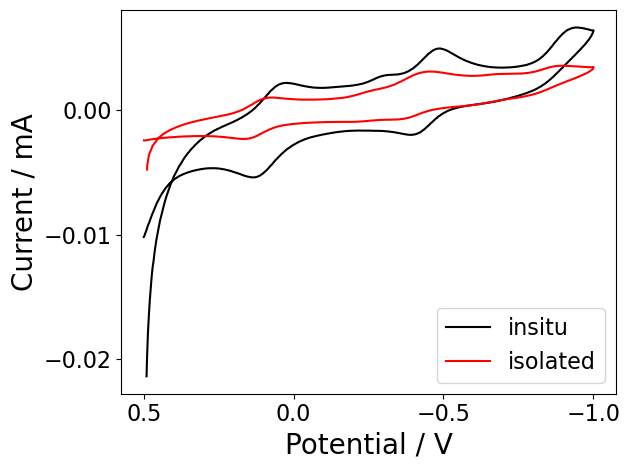

In [3]:
plt.figure()

for i, fname in enumerate(target_files):
    fpath = os.path.join(data_dir, fname)
    if not os.path.exists(fpath):
        print(f"Missing file: {fname}")
        continue

    mpr = BioLogic.MPRfile(fpath)
    df  = pd.DataFrame(mpr.data)

    potential_col = find_column(df, ["Ewe/V", "Ecell/V"])
    current_col   = find_column(df, ["I/mA", "<I>/mA", "I/A"])
    if potential_col is None or current_col is None:
        print(f"Could not find required columns in {fname}: {df.columns.tolist()}")
        continue

    if cycle_to_plot is not None and "cycle number" in df.columns:
        df = df[df["cycle number"] == cycle_to_plot]

    current   = df[current_col] * (1000 if current_col == "I/A" else 1)
    potential = df[potential_col] - Fc_cv if Fc_cv is not None else df[potential_col]

    plt.plot(potential, -current, color=colors[i], label=file_labels[i])

plt.gca().invert_xaxis()
plt.xlabel("E vs Fc / V" if Fc_cv is not None else "Potential / V", fontsize=20)
plt.ylabel("Current / mA", fontsize=20)
plt.locator_params(axis='x', nbins=4)
plt.locator_params(axis='y', nbins=4)
plt.tick_params(axis='both', labelsize=16)
plt.legend(fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(data_dir, "cv.png"), dpi=300)
plt.show()

---
#### SWV

In [6]:
# ========= SWV USER INPUT =========

swv_data_dir   = r".\..\HT-3-032\swv"
swv_base_files = ["0eq", "0.5eq", "1eq", "2eq", "3eq"]
swv_target_files = [f"{name}_C01.mpr" for name in swv_base_files]
swv_colors     = ["black", "red", "blue", "green", "orange", "purple"]
swv_file_labels = [f"{name}" for name in swv_base_files]
Fc_swv         = None      # e.g. 0.8 — set to None to skip Fc referencing
# ===================================

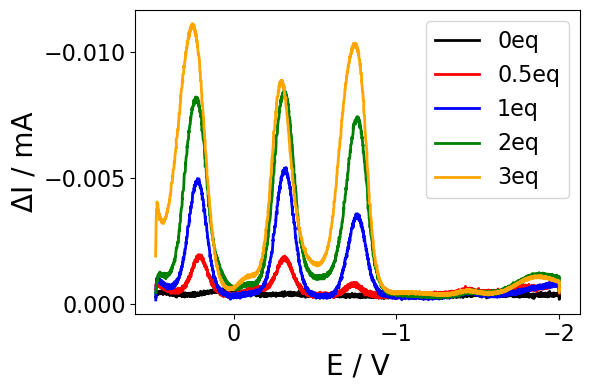

In [7]:
plt.figure(figsize=(6, 4))

for i, fname in enumerate(swv_target_files):
    fpath = os.path.join(swv_data_dir, fname)
    if not os.path.exists(fpath):
        print(f"Missing file: {fname}")
        continue

    mpr = BioLogic.MPRfile(fpath)
    df  = pd.DataFrame(mpr.data)

    E_forward  = df["Ewe/V"].iloc[::2].values
    I_forward  = df["<I>/mA"].iloc[::2].values
    I_backward = df["<I>/mA"].iloc[1::2].values

    n       = min(len(I_forward), len(I_backward))
    delta_I = I_forward[:n] - I_backward[:n]
    E       = E_forward[:n] - Fc_swv if Fc_swv is not None else E_forward[:n]

    plt.plot(E, delta_I, color=swv_colors[i], linewidth=2, label=swv_file_labels[i])

plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.xlabel("E vs Fc / V" if Fc_swv is not None else "E / V", fontsize=20)
plt.ylabel("ΔI / mA", fontsize=20)
plt.locator_params(axis='x', nbins=4)
plt.locator_params(axis='y', nbins=4)
plt.tick_params(axis='both', labelsize=16)
plt.legend(fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(swv_data_dir, "swv.png"), dpi=300)
plt.show()